# Mixed-Triangle Neighborhood Analysis for the 20260324 NVT Batch

This notebook reads the finished `aab_abb_triangle_neighbors.csv` files under
`results/20260324_NVT_batch_xyz_saving` and makes the requested temperature-overlap plots.

Required plots:

- mixed-triangle area histogram for `AAB + ABB`, averaged equally over frames
- `AAB` neighbor-count histograms for `Na`, `NA`, `NB`, and `Nb`
- `ABB` neighbor-count histograms for `Na`, `NA`, `NB`, and `Nb`

Extra plots included here:

- mixed-triangle abundance vs temperature
- mean mixed-triangle area vs temperature
- heatmaps of mean neighbor counts vs temperature

Notes:

- `Na = near_AAB`
- `NA = near_AAA`
- `NB = near_BBB`
- `Nb = near_ABB` (equivalently the mixed `BBA` neighborhood)
- histograms are built by averaging per-frame normalized histograms, so each frame has equal weight


In [5]:
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in (start, *start.parents):
        if (candidate / "python" / "particle_csv.py").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root()
PYTHON_ROOT = REPO_ROOT / "python"
if str(PYTHON_ROOT) not in sys.path:
    sys.path.insert(0, str(PYTHON_ROOT))

importlib.invalidate_caches()
import analysis_triangle_neighbor_plots as triangle_neighbor_plots
triangle_neighbor_plots = importlib.reload(triangle_neighbor_plots)

build_triangle_neighbor_dataset = triangle_neighbor_plots.build_triangle_neighbor_dataset
discover_triangle_neighbor_results = triangle_neighbor_plots.discover_triangle_neighbor_results
make_summary_table = triangle_neighbor_plots.make_summary_table
plot_abundance_vs_temperature = triangle_neighbor_plots.plot_abundance_vs_temperature
plot_area_overlay = triangle_neighbor_plots.plot_area_overlay
plot_frame_mixed_area_sum_histogram = triangle_neighbor_plots.plot_frame_mixed_area_sum_histogram
plot_mean_area_vs_temperature = triangle_neighbor_plots.plot_mean_area_vs_temperature
plot_neighbor_heatmaps = triangle_neighbor_plots.plot_neighbor_heatmaps
plot_neighbor_histograms = triangle_neighbor_plots.plot_neighbor_histograms

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 160)

RESULT_ROOT = REPO_ROOT / "results" / "20260324_NVT_batch_xyz_saving"
FIGURE_DIR = REPO_ROOT / "results" / "triangle_neighbor_figures" / "20260324_nvt"
AREA_BIN_COUNT = 120
CHUNK_SIZE = 1_000_000

manifest = discover_triangle_neighbor_results(RESULT_ROOT)
display(manifest.assign(csv_path=manifest["csv_path"].astype(str)))
print(f"Found {len(manifest)} temperature CSVs.")
print(f"Figures will be written to: {FIGURE_DIR}")


,temperature,temperature_label,csv_path
0,0.5,T=0.5,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.5/aab_abb_triangle_neighbors.csv
1,0.6,T=0.6,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.6/aab_abb_triangle_neighbors.csv
2,0.7,T=0.7,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.7/aab_abb_triangle_neighbors.csv
3,0.8,T=0.8,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.8/aab_abb_triangle_neighbors.csv
4,0.9,T=0.9,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.9/aab_abb_triangle_neighbors.csv
5,1.0,T=1.0,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=1.0/aab_abb_triangle_neighbors.csv


Found 6 temperature CSVs.
Figures will be written to: /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/triangle_neighbor_figures/20260324_nvt


In [6]:
analysis = build_triangle_neighbor_dataset(
    result_root=RESULT_ROOT,
    area_bin_count=AREA_BIN_COUNT,
    chunksize=CHUNK_SIZE,
    verbose=True,
)

summary_df = make_summary_table(analysis)
display(summary_df)


Processing /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.5/aab_abb_triangle_neighbors.csv
Processing /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.6/aab_abb_triangle_neighbors.csv
Processing /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.7/aab_abb_triangle_neighbors.csv
Processing /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.8/aab_abb_triangle_neighbors.csv
Processing /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=0.9/aab_abb_triangle_neighbors.csv
Processing /nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/20260324_NVT_batch_xyz_saving/T=1.0/aab_abb_triangle_neighbors.csv


,temperature,frames_total,frames_with_mixed,frames_with_AAB,frames_with_ABB,mean_AAB_per_frame,mean_ABB_per_frame,mean_AAB_area,mean_ABB_area
0,0.5,6000,6000,6000,6000,155.238667,158.133333,1.039111,1.032186
1,0.6,6000,6000,6000,6000,242.942000,230.666500,0.850057,0.852029
2,0.7,6000,6000,6000,6000,321.222833,308.480167,0.797905,0.797521
3,0.8,6000,6000,6000,6000,489.075333,460.757833,0.764622,0.766377
4,0.9,6000,6000,6000,6000,581.793500,561.363000,0.750352,0.749663
5,1.0,6000,6000,6000,6000,803.043000,849.308667,0.736840,0.737421


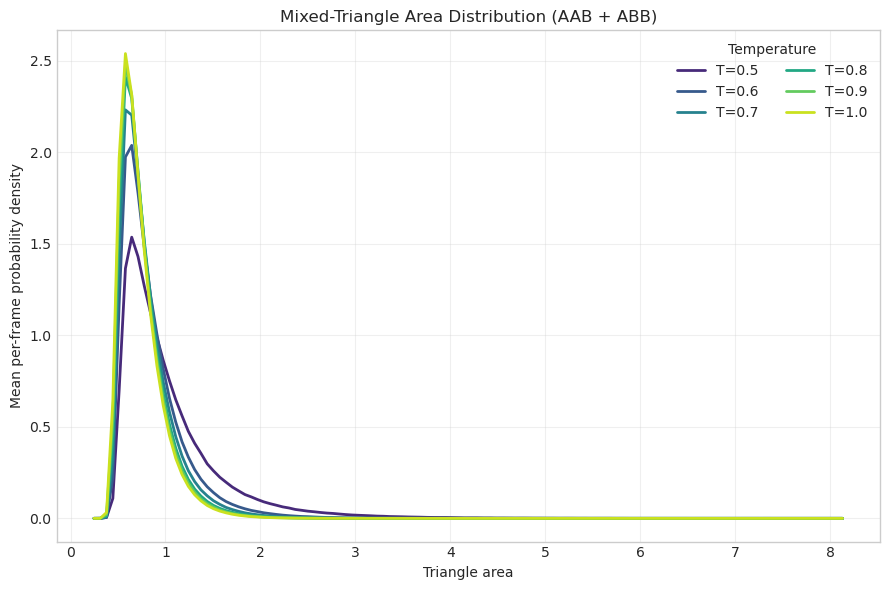

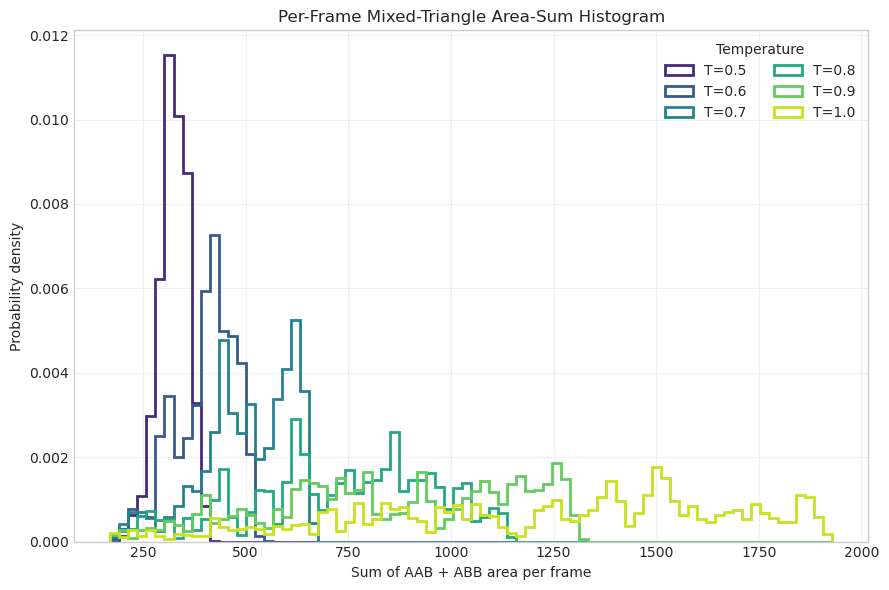

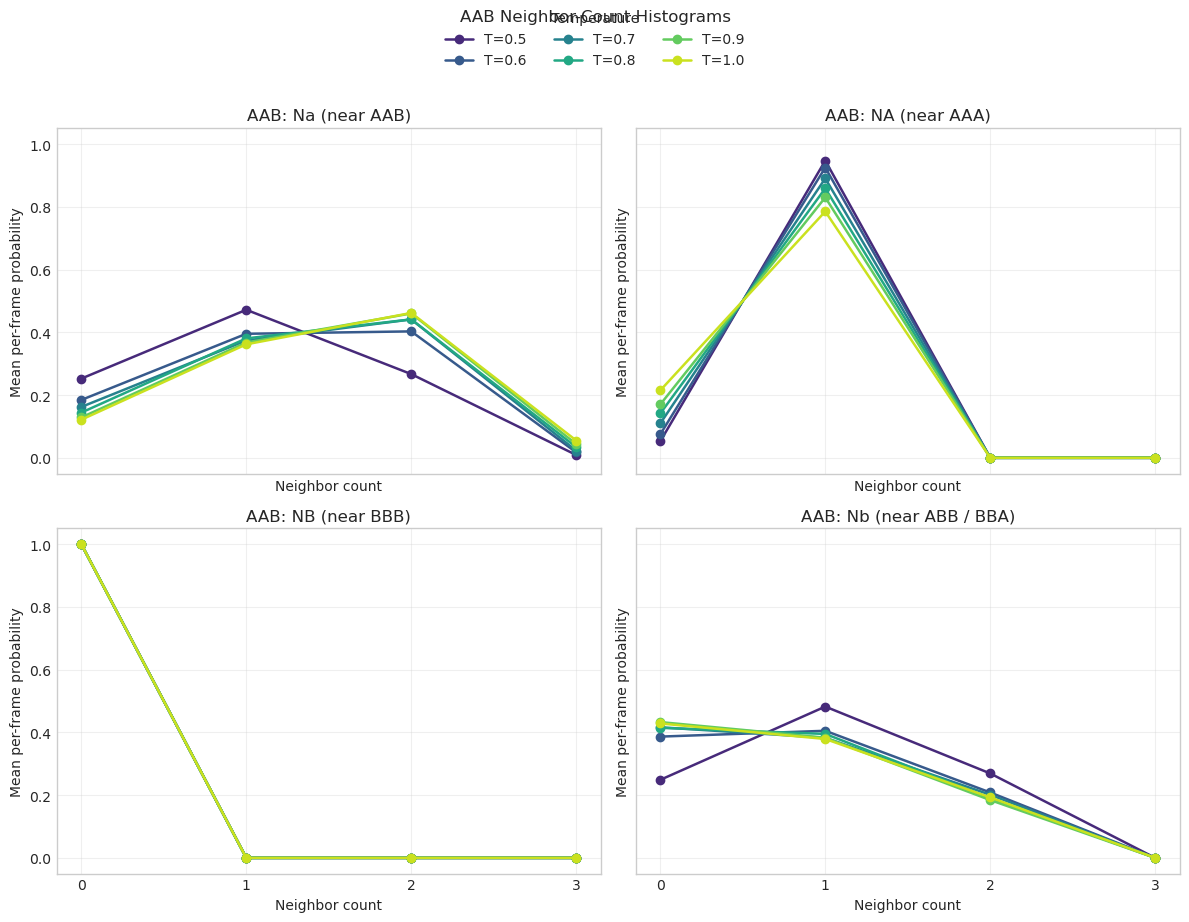

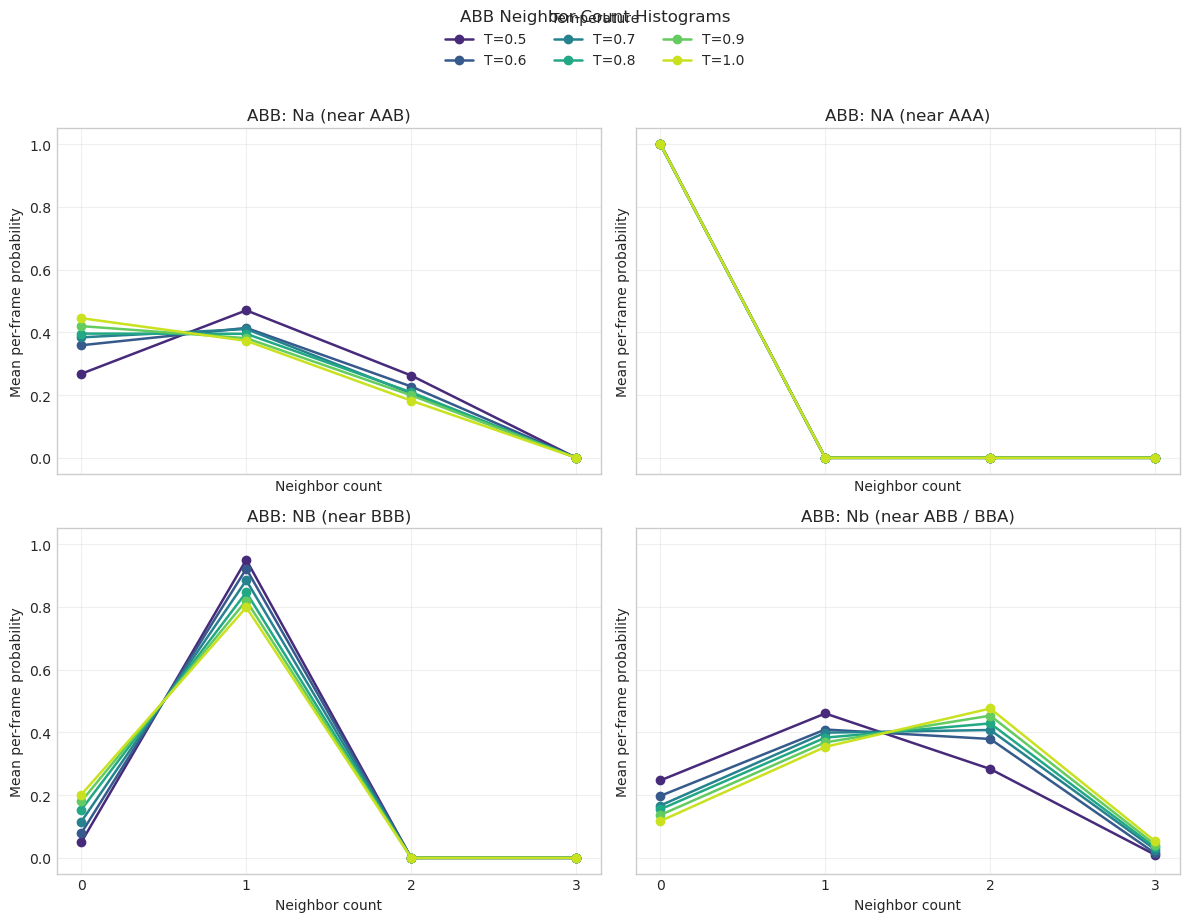

In [7]:
figure_paths = {}

plot_area_overlay(analysis, figure_dir=FIGURE_DIR)
figure_paths["mixed_triangle_area_overlay"] = FIGURE_DIR / "mixed_triangle_area_overlay.png"
plt.show()

plot_frame_mixed_area_sum_histogram(analysis, figure_dir=FIGURE_DIR)
figure_paths["mixed_triangle_area_sum_per_frame_histogram_overlay"] = FIGURE_DIR / "mixed_triangle_area_sum_per_frame_histogram_overlay.png"
plt.show()

plot_neighbor_histograms(analysis, triangle_type="AAB", figure_dir=FIGURE_DIR)
figure_paths["aab_neighbor_histograms"] = FIGURE_DIR / "aab_neighbor_histograms.png"
plt.show()

plot_neighbor_histograms(analysis, triangle_type="ABB", figure_dir=FIGURE_DIR)
figure_paths["abb_neighbor_histograms"] = FIGURE_DIR / "abb_neighbor_histograms.png"
plt.show()


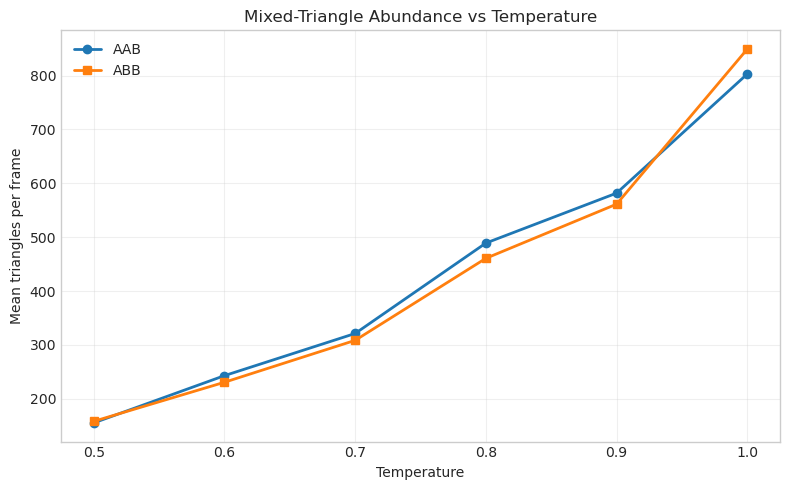

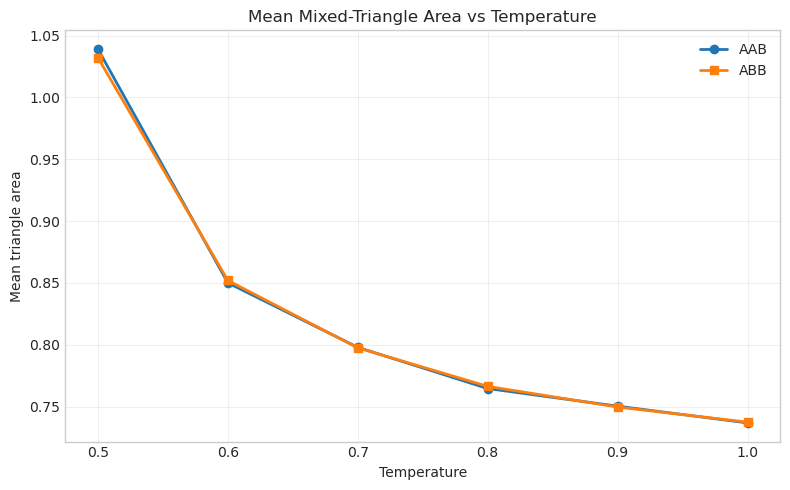

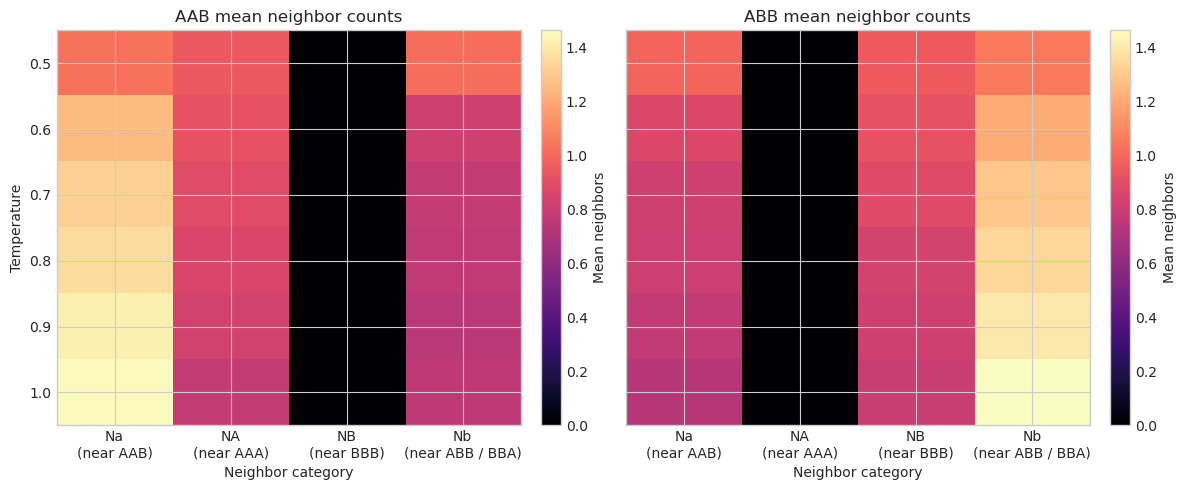

,figure,path
0,mixed_triangle_area_overlay,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/triangle_neighbor_figures/20260324_nvt/mixed_triangle_area_overlay.png
1,mixed_triangle_area_sum_per_frame_histogram_overlay,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/triangle_neighbor_figures/20260324_nvt/mixed_triangle_area_sum_per_frame_histogram_overlay.png
2,aab_neighbor_histograms,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/triangle_neighbor_figures/20260324_nvt/aab_neighbor_histograms.png
3,abb_neighbor_histograms,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/triangle_neighbor_figures/20260324_nvt/abb_neighbor_histograms.png
4,mixed_triangle_abundance_vs_temperature,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/triangle_neighbor_figures/20260324_nvt/mixed_triangle_abundance_vs_temperature.png
5,mixed_triangle_mean_area_vs_temperature,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/triangle_neighbor_figures/20260324_nvt/mixed_triangle_mean_area_vs_temperature.png
6,mixed_triangle_neighbor_heatmaps,/nfs/roberts/scratch/pi_co54/bh692/MD_Simulation_CUDA/results/triangle_neighbor_figures/20260324_nvt/mixed_triangle_neighbor_heatmaps.png


In [8]:
plot_abundance_vs_temperature(analysis, figure_dir=FIGURE_DIR)
figure_paths["mixed_triangle_abundance_vs_temperature"] = FIGURE_DIR / "mixed_triangle_abundance_vs_temperature.png"
plt.show()

plot_mean_area_vs_temperature(analysis, figure_dir=FIGURE_DIR)
figure_paths["mixed_triangle_mean_area_vs_temperature"] = FIGURE_DIR / "mixed_triangle_mean_area_vs_temperature.png"
plt.show()

plot_neighbor_heatmaps(analysis, figure_dir=FIGURE_DIR)
figure_paths["mixed_triangle_neighbor_heatmaps"] = FIGURE_DIR / "mixed_triangle_neighbor_heatmaps.png"
plt.show()

display(
    pd.DataFrame(
        {
            "figure": list(figure_paths.keys()),
            "path": [str(path) for path in figure_paths.values()],
        }
    )
)
